# Unemployment Analysis in India

## Project Objective

This project explores unemployment trends in India using Python.

The analysis looks at:
- Differences in average unemployment rates across regions
- Month-wise unemployment trends
- Unemployment trends for selected regions over time
- The relationship between unemployment, employment, and labour participation
- Changes in unemployment around the COVID-19 lockdown period

The project uses Pandas for data analysis and Matplotlib and Seaborn for visualization.

**Dataset:** Unemployment in India dataset, covering monthly observations from May 2019 to June 2020.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)

## 1. Data Loading and Inspection

First, we load the CSV file and check the number of rows, columns, and the first few records.

In [2]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Column names:")
print(df.columns.tolist())

print("\nData types before cleaning:")
print(df.dtypes)

Column names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Data types before cleaning:
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object


In [4]:
# Check missing values before removing empty rows
print("Missing values:")
print(df.isnull().sum())


Missing values:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


### Data Cleaning

The dataset contains completely empty rows. These rows do not contain useful information, so they are removed.

We also remove extra spaces from text values and convert the date and numerical columns into the correct data types.

In [5]:
# Remove completely empty rows
df = df.dropna(how="all").reset_index(drop=True)

print("Rows after removing empty rows:", len(df))
print("Duplicate rows after removing empty rows:", df.duplicated().sum())

# Clean text columns
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("string").str.strip()

# Convert date and numerical columns
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y", errors="coerce")

numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing values in important columns
df = df.dropna(subset=["Region", "Date"] + numeric_cols).reset_index(drop=True)

# Create useful time columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

print("Shape after cleaning:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())


Rows after removing empty rows: 740
Duplicate rows after removing empty rows: 0
Shape after cleaning: (740, 10)
Date range: 2019-05-31 to 2020-06-30


**Observation:** The original CSV contains 768 rows, including 28 completely empty rows. After removing those rows and checking the data types, the dataset contains **740 valid records** covering **28 regions** from **May 2019 to June 2020**. The data includes both Rural and Urban observations.

Because the dataset ends in June 2020, this analysis can show the short-term change around the first COVID-19 lockdown, but it cannot describe the longer-term recovery after the pandemic.

## 2. Exploratory Data Analysis

### 2.1 Region-wise Average Unemployment Rate

We calculate the average unemployment rate for each region over the full period.

In [6]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

region_avg.to_frame("Average Unemployment Rate (%)")

,Average Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


**Observation:** The average unemployment rate varies considerably across regions. Tripura, Haryana, and Jharkhand have the highest average rates in this dataset, while Meghalaya, Odisha, and Chhattisgarh have lower averages.

These values describe this dataset and time period; they should not be treated as a ranking of current unemployment conditions.

### 2.2 Month-wise Unemployment Trend

Next, we calculate the average unemployment rate for each calendar month across all years available in the dataset.

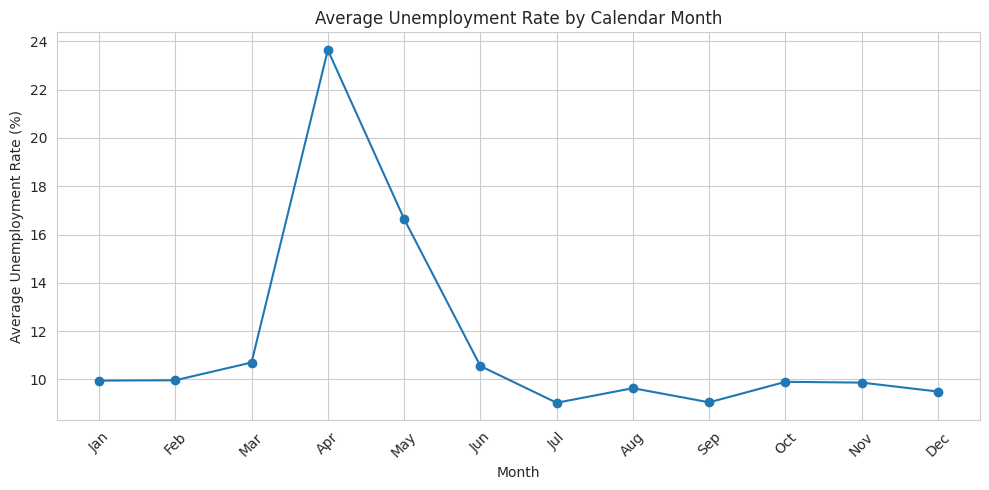

In [7]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

month_avg = (
    df.groupby("Month_Name")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(month_order)
    .dropna()
)

plt.figure(figsize=(10, 5))
plt.plot(month_avg.index, month_avg.values, marker="o")
plt.title("Average Unemployment Rate by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The monthly averages are noticeably higher in April and May. This pattern is strongly influenced by the sharp unemployment increase during April-May 2020. Therefore, the chart should not be interpreted as a normal seasonal pattern because the dataset contains only one year with COVID-19 lockdown months.

## 3. Time-Series Trend for Selected Regions

The following chart compares unemployment rates over time for four selected regions: Maharashtra, Uttar Pradesh, Tamil Nadu, and Delhi.

Rural and Urban observations are averaged when both are available for the same region and date.

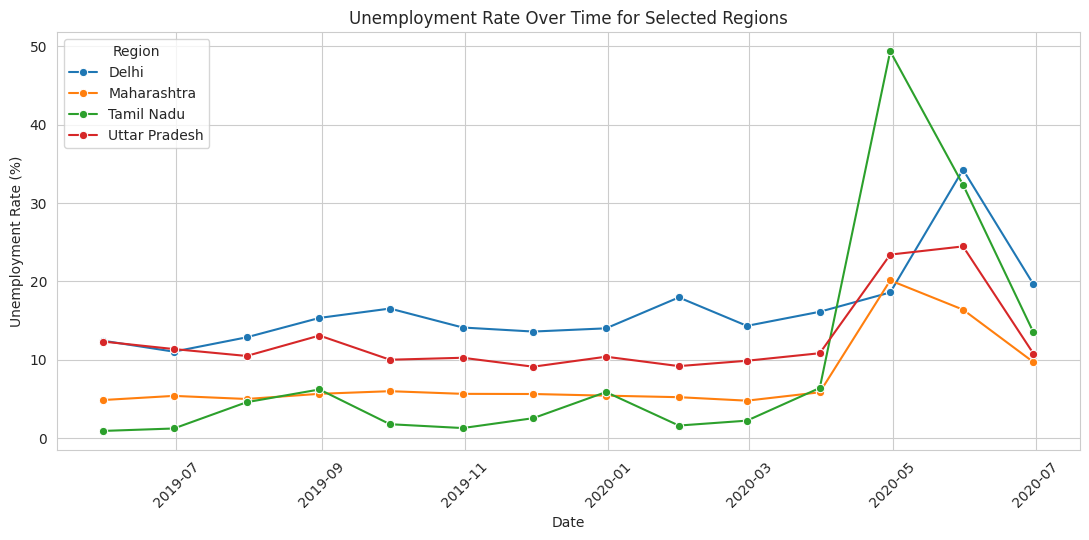

In [8]:
selected_regions = ["Maharashtra", "Uttar Pradesh", "Tamil Nadu", "Delhi"]

ts_data = (
    df[df["Region"].isin(selected_regions)]
    .groupby(["Region", "Date"])["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5.5))
sns.lineplot(
    data=ts_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time for Selected Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.tight_layout()
plt.show()

**Observation:** The four selected regions show relatively moderate unemployment rates before the lockdown period, followed by sharp increases around April-May 2020. The size and timing of the increase differ by region. Tamil Nadu shows a particularly large April 2020 increase in this dataset, while Delhi also records a high rate during the same period.

## 4. Top 10 Regions with the Highest Average Unemployment Rate

This bar chart shows the ten regions with the highest average unemployment rate over the available period.

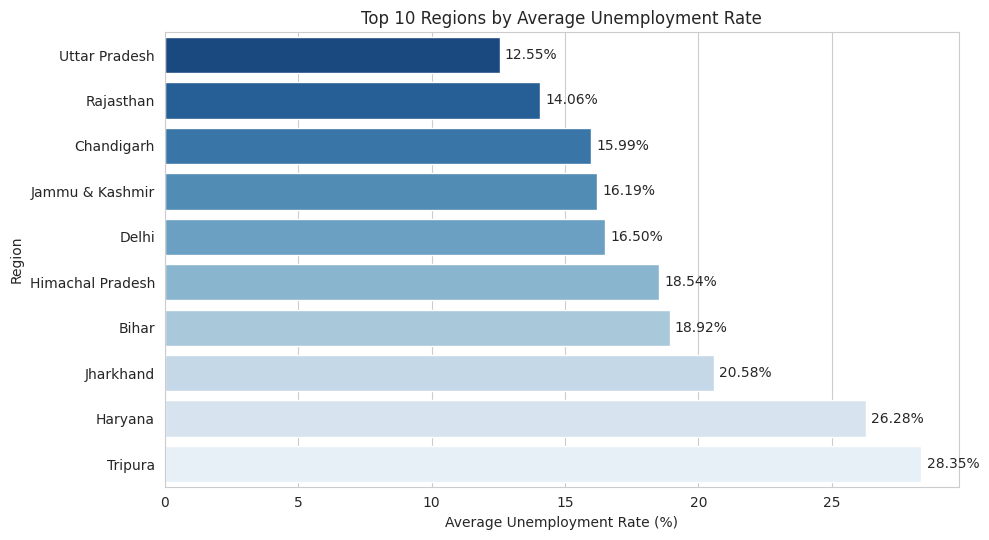

In [9]:
top10 = region_avg.head(10).sort_values()

plt.figure(figsize=(10, 5.5))
sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

for i, value in enumerate(top10.values):
    plt.text(value + 0.2, i, f"{value:.2f}%", va="center")

plt.tight_layout()
plt.show()

**Observation:** Tripura has the highest average unemployment rate in the dataset, followed by Haryana and Jharkhand. The chart shows that unemployment levels differ substantially between regions during the period covered by the dataset.

## 5. Correlation Analysis

The heatmap shows the correlation between:
- Unemployment rate
- Estimated number of employed people
- Labour participation rate

A correlation close to +1 means a strong positive relationship, close to -1 means a strong negative relationship, and close to 0 means little linear relationship.

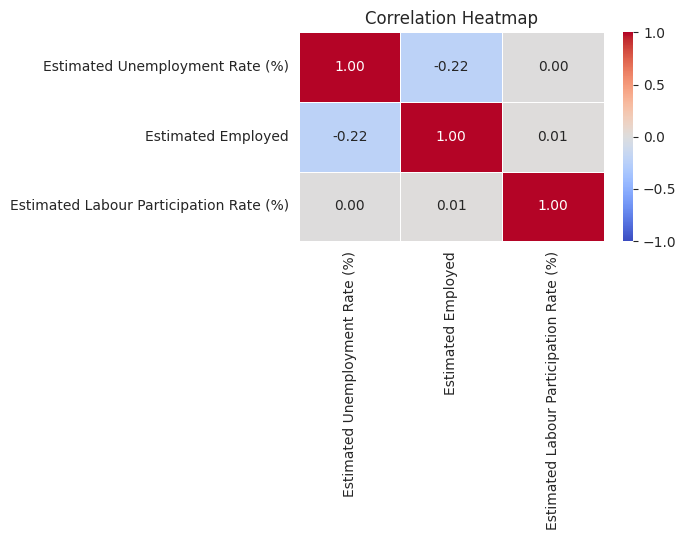

In [10]:
corr_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation:** In this dataset, unemployment rate has a weak negative correlation with the estimated number of employed people (about -0.22) and almost no linear correlation with labour participation rate (about 0.00).

The number of employed people is also almost uncorrelated with labour participation rate in the combined dataset. These relationships should be interpreted carefully because the data combines different regions, areas, and population sizes.

## 6. Pre-COVID vs. COVID-Lockdown Period

India's nationwide COVID-19 lockdown began in late March 2020.

To avoid treating March as a fully pre-lockdown or fully lockdown month, we use:
- **Pre-COVID:** before March 2020
- **COVID period:** April to June 2020
- **March 2020:** treated as a transition month and excluded from the two-group comparison

This gives a cleaner comparison of the period before the lockdown and the months immediately after it began.

In [11]:
pre_covid = df[df["Date"] < pd.Timestamp("2020-03-01")]

covid_period = df[
    (df["Date"] >= pd.Timestamp("2020-04-01")) &
    (df["Date"] <= pd.Timestamp("2020-06-30"))
]

period_comparison = pd.DataFrame({
    "Pre-COVID": pre_covid[numeric_cols].mean(),
    "COVID Period": covid_period[numeric_cols].mean()
}).round(2)

period_comparison

,Pre-COVID,COVID Period
Estimated Unemployment Rate (%),9.51,20.19
Estimated Employed,7466027.87,6175310.93
Estimated Labour Participation Rate (%),43.89,38.05


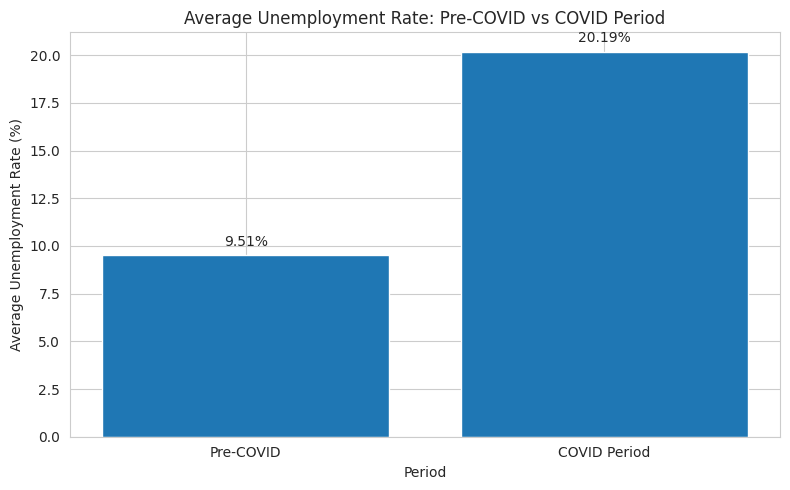

In [12]:
plt.figure(figsize=(8, 5))

values = period_comparison.loc[
    "Estimated Unemployment Rate (%)"
]

bars = plt.bar(values.index, values.values)

plt.title("Average Unemployment Rate: Pre-COVID vs COVID Period")
plt.ylabel("Average Unemployment Rate (%)")
plt.xlabel("Period")

for bar, value in zip(bars, values.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

**Observation:** The average unemployment rate increases from about **9.51% before COVID-19** to about **20.19% during April-June 2020** in this dataset. At the same time, the average estimated employment and labour participation rate are lower during the COVID period.

The increase coincides with the first COVID-19 lockdown period. The dataset alone cannot prove that COVID-19 was the only cause of the change.

## 7. Final Conclusion

- Unemployment rates vary substantially across the regions included in the dataset.
- Tripura, Haryana, and Jharkhand have the highest average unemployment rates over the period studied.
- April and May 2020 show a clear increase in unemployment, which is also visible in the time-series charts.
- The selected regions experienced different levels of increase during the COVID-19 period.
- The correlation analysis shows only a weak relationship between unemployment and estimated employment, while the relationship with labour participation is close to zero in the combined dataset.
- Comparing the periods before March 2020 with April-June 2020 shows a large increase in average unemployment.
- The dataset covers only May 2019 to June 2020, so the analysis is focused on the short-term labour-market change around the first COVID-19 lockdown rather than long-term unemployment trends.

Overall, the project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to clean data, explore regional and time-based patterns, and study changes in unemployment during an important period.